# Analisis de Modelos Nucleares: MISR vs Base SR

Este notebook analiza los resultados de predicción de la Energía de Enlace (Binding Energy) generados por el script `run_comparison.py`, comparando nuestra implementación multiobjetivo **MISR** contra el modelo base de **nuclearpy**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuracion estetica
plt.style.use('seaborn-v0_8-muted')
sns.set_context("talk")
figsize = (14, 10)

### 1. Carga de Datos
Cargamos el archivo `comparison_results.csv` generado anteriormente.

In [2]:
df = pd.read_csv('comparison_results.csv')
print(f"Total de nucleos analizados: {len(df)}")
df.head()

Total de nucleos analizados: 274


,N,Z,A,True_BE_MeV,MISR_Pred_MeV,MISR_Error,Base_SR_Pred_MeV,Base_SR_Error
0,39,41,80,652.080000,659.987825,-7.907825,651.451545,0.628455
1,25,18,43,364.994243,371.352256,-6.358014,366.478823,-1.484581
2,49,49,98,806.540000,813.117010,-6.577010,807.190635,-0.650635
3,28,30,58,486.964909,483.839186,3.125723,486.579267,0.385642
4,38,30,68,595.386376,592.118239,3.268137,596.546741,-1.160365


### 2. Calculo de Metricas Globales

In [3]:
def get_metrics(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

misr_metrics = get_metrics(df['True_BE_MeV'], df['MISR_Pred_MeV'])
base_metrics = get_metrics(df['True_BE_MeV'], df['Base_SR_Pred_MeV'])

metrics_df = pd.DataFrame([misr_metrics, base_metrics], index=['MISR Model', 'Base SR (nuclearpy)'])
metrics_df

,RMSE,MAE,R2
MISR Model,6.212339,3.978638,0.999305
Base SR (nuclearpy),1.057968,0.828992,0.999980


### 3. Visualizacion de Predicciones
Comparamos los valores reales vs los predichos para ambos modelos.

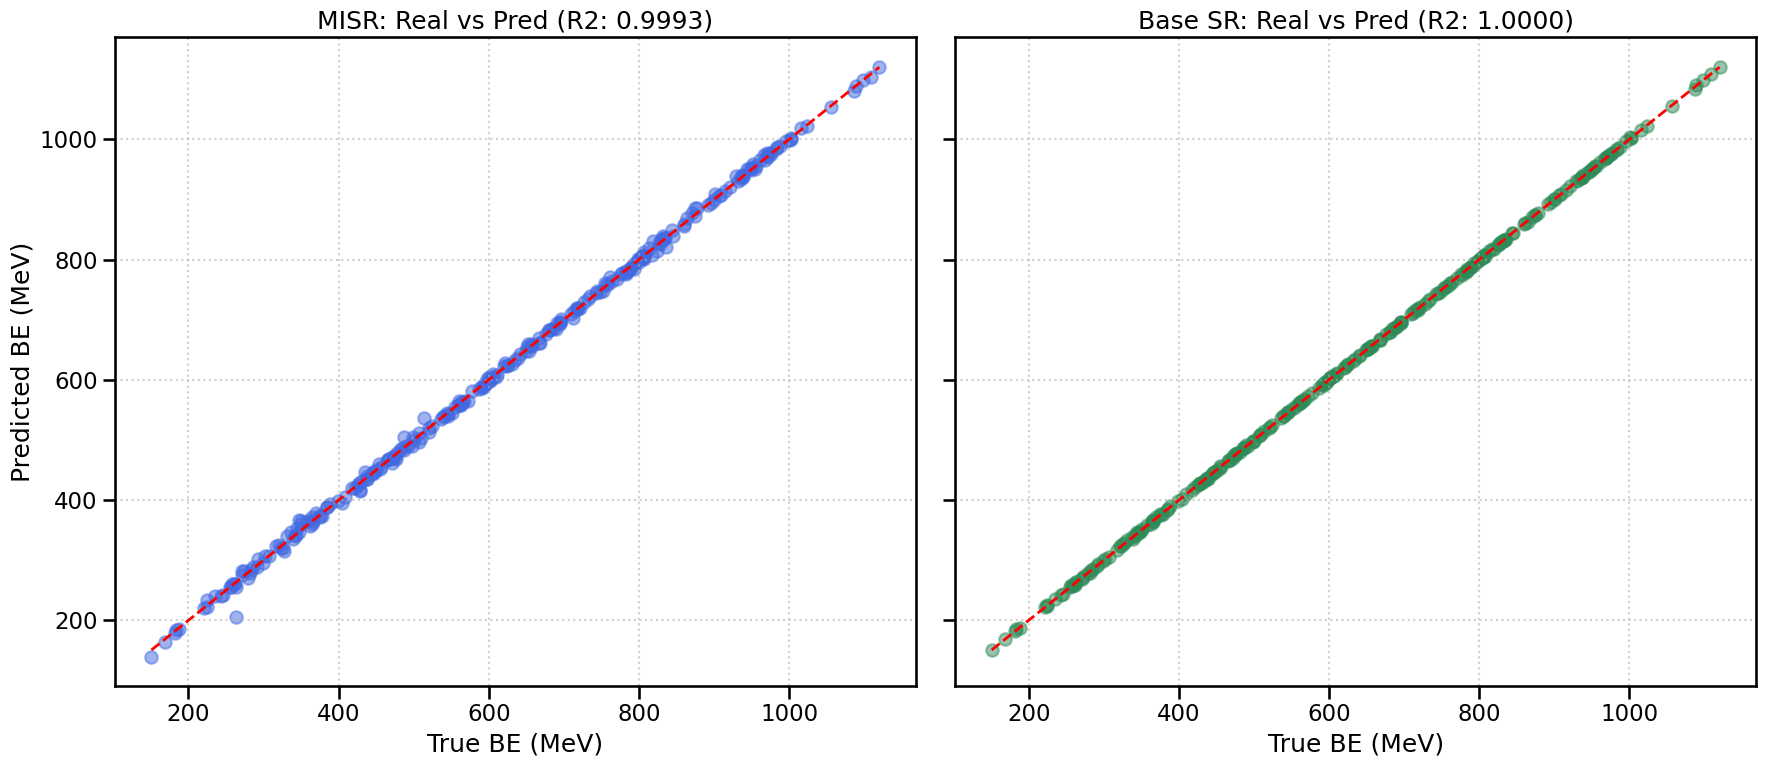

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# MISR
ax1.scatter(df['True_BE_MeV'], df['MISR_Pred_MeV'], alpha=0.5, color='royalblue', label='MISR')
ax1.plot([df['True_BE_MeV'].min(), df['True_BE_MeV'].max()], [df['True_BE_MeV'].min(), df['True_BE_MeV'].max()], 'r--', lw=2)
ax1.set_title(f"MISR: Real vs Pred (R2: {misr_metrics['R2']:.4f})")
ax1.set_xlabel("True BE (MeV)")
ax1.set_ylabel("Predicted BE (MeV)")
ax1.grid(True, linestyle=':', alpha=0.6)

# Base SR
ax2.scatter(df['True_BE_MeV'], df['Base_SR_Pred_MeV'], alpha=0.5, color='seagreen', label='Base SR')
ax2.plot([df['True_BE_MeV'].min(), df['True_BE_MeV'].max()], [df['True_BE_MeV'].min(), df['True_BE_MeV'].max()], 'r--', lw=2)
ax2.set_title(f"Base SR: Real vs Pred (R2: {base_metrics['R2']:.4f})")
ax2.set_xlabel("True BE (MeV)")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 4. Distribucion de Errores (Residuos)
Analizamos como se distribuyen los errores en toda la muestra.

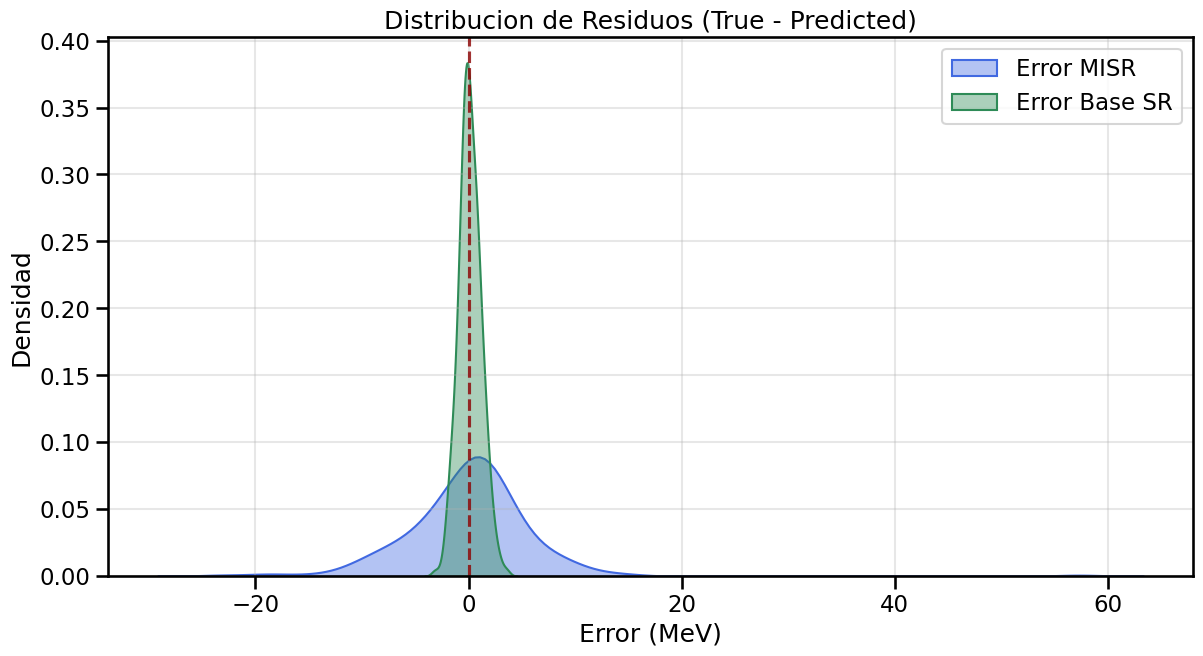

In [5]:
plt.figure(figsize=(14, 7))
sns.kdeplot(df['MISR_Error'], label='Error MISR', fill=True, color='royalblue', alpha=0.4)
sns.kdeplot(df['Base_SR_Error'], label='Error Base SR', fill=True, color='seagreen', alpha=0.4)
plt.axvline(0, color='darkred', linestyle='--', alpha=0.8)
plt.title("Distribucion de Residuos (True - Predicted)")
plt.xlabel("Error (MeV)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5. Analisis por Masa (A)
Observamos si el error depende de la masa atomica de los nucleos.

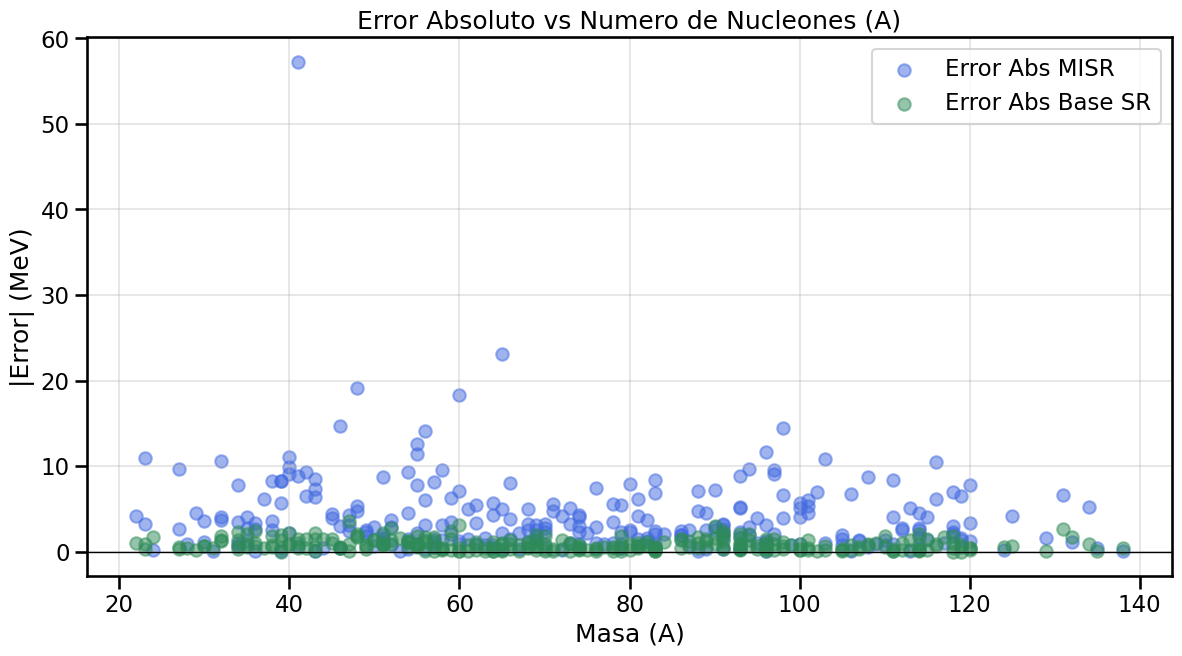

In [6]:
plt.figure(figsize=(14, 7))
plt.scatter(df['A'], df['MISR_Error'].abs(), alpha=0.5, label='Error Abs MISR', color='royalblue')
plt.scatter(df['A'], df['Base_SR_Error'].abs(), alpha=0.5, label='Error Abs Base SR', color='seagreen')
plt.axhline(0, color='black', lw=1)
plt.title("Error Absoluto vs Numero de Nucleones (A)")
plt.xlabel("Masa (A)")
plt.ylabel("|Error| (MeV)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()